In [1]:
import numpy as np
import torch
import torch.nn as nn

import sys
sys.path.insert(0, '../include')

from plot import plot_wavefunction, plot_wavefunctions
from sampling import TrainConfig
from scipy_eigensolver import solve_1channel
from training import train_Rayleigh, train_Rayleigh_PDE
from validation import validate, print_metrics

Define parameters

In [2]:
V0 = 59.66
R0 = 1.5

r_min = 1e-4
r_max = 30.0
r = np.linspace(r_min, r_max, 1000)

Solve with scipy

Ground state energy E = -2.224925 MeV


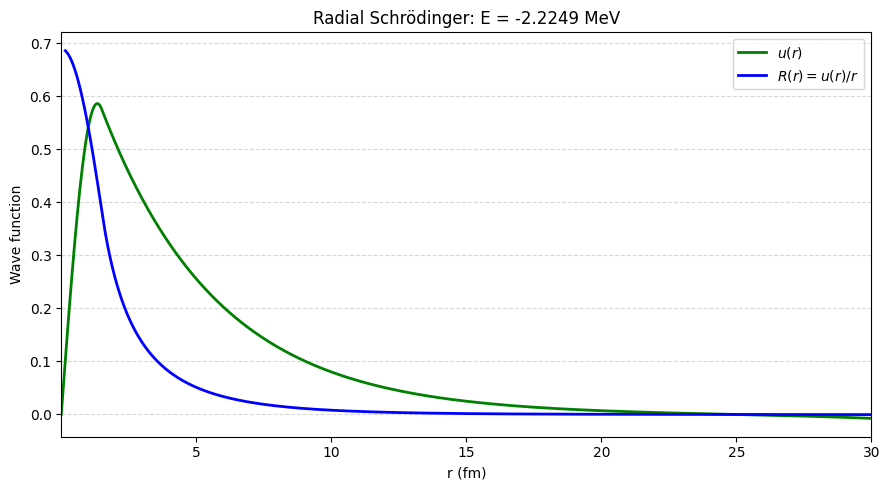

In [4]:
def square_well(r):
    return np.where(r <= R0, -V0, 0.0)

E_scipy, u_scipy, R_scipy = solve_1channel(square_well, r)
plot_wavefunction(r, u_scipy, R_scipy, E_scipy)

Define a neural network $N_\theta(r)$ that approximates the radial wave function via an ansatz
$$
u_\theta(r) = r e^{-\alpha r} N_{\theta}(r) \text{ with } \alpha = 0.25 \text{ fm}^{-1}.
$$
The network input is rescaled from $[0,r_{\max}]$ to $[-1,1]$.

In [7]:
class RadialNet(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, alpha=0.25, energy_init=-3.0):
        # Define layers
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self.register_buffer('alpha', torch.tensor(float(alpha)))
        self.energy = nn.Parameter(torch.tensor([energy_init], dtype=torch.float32))

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.dtype = torch.float32

        self.r_min = r_min
        self.r_max = r_max
        self.R = R0

    # Forward pass
    def forward(self, r):
        # r is expected to be of shape (N, 1)
        x = 2.0 * r / self.r_max - 1.0 # mapping to [-1,1]
        return r * torch.exp(-self.alpha * r) * self.net(x)

    # Potential
    def potential(self, r):
        return torch.where(r <= R0, -V0, torch.tensor(0.0))

Train with Rayleigh energy only

In [14]:
cfg = TrainConfig()
cfg.n_rayleigh = 5000

model = RadialNet()

history = train_Rayleigh(model, cfg, stop=1e-3)

{'step': 1, 'loss': 2.0757739543914795, 'rayleigh': 0.0788380429148674, 'norm_loss': 0.199685737490654, 'boundary_loss': 7.834177267795894e-06, 'E': 0.0788380429148674}
{'step': 500, 'loss': -2.8696320056915283, 'rayleigh': -3.0322139263153076, 'norm_loss': 0.0162506103515625, 'boundary_loss': 7.573074526590062e-06, 'E': -3.0322139263153076}
{'step': 1000, 'loss': -1.8896353244781494, 'rayleigh': -1.8947638273239136, 'norm_loss': 0.0005115144303999841, 'boundary_loss': 1.3383447594605968e-06, 'E': -1.8947638273239136}
{'step': 1500, 'loss': -0.9058522582054138, 'rayleigh': -0.9783207774162292, 'norm_loss': 0.0072458949871361256, 'boundary_loss': 9.59683688961377e-07, 'E': -0.9783207774162292}
{'step': 2000, 'loss': -3.310840606689453, 'rayleigh': -3.315638780593872, 'norm_loss': 0.000479489826830104, 'boundary_loss': 3.334638734031614e-07, 'E': -3.315638780593872}
{'step': 2500, 'loss': -0.7156468629837036, 'rayleigh': -0.7292293906211853, 'norm_loss': 0.001357437577098608, 'boundary_l

In [15]:
metrics, u_nn, R_nn = validate(r, u_scipy, R_scipy, E_scipy, model)
print_metrics(metrics)

  rayleigh_energy: -1.9576627
  norm_loss: 0.0015279052
  pde_loss: 1.6503235
  u_rmax: -0.0012835505
  l2: 0.039277809
  learned_energy: -2.1627724
  energy_error: 0.06215273


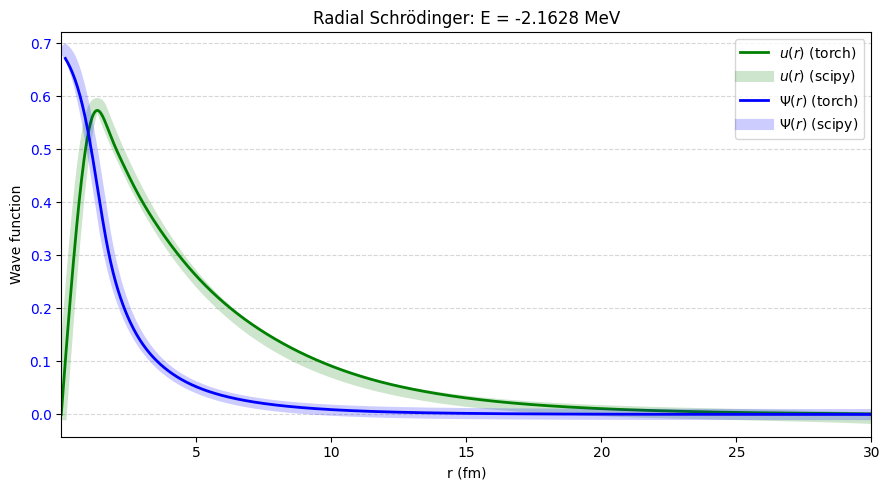

In [16]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn, R_nn, metrics['learned_energy'])

Train with both Rayleigh and PDE terms

In [58]:
cfg2 = TrainConfig()
cfg2.n_origin = 2000
cfg2.n_pde = 8000
cfg2.n_rayleigh = 8000
cfg2.grad_balance_pde_scale = 3.0
#cfg2.grad_balance_match_scale = 2.0

model2 = RadialNet()

history2 = train_Rayleigh_PDE(model2, cfg2, stop=1e-4)

{'step': 1, 'loss': 2.4536564350128174, 'rayleigh': 0.031862158328294754, 'pde_loss': 3.7554543018341064, 'match_loss': 9.19218921661377, 'norm_loss': 0.24217742681503296, 'boundary_loss': 1.9697592961165356e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 500, 'loss': -1.0886335372924805, 'rayleigh': -1.188019037246704, 'pde_loss': 76.2885513305664, 'match_loss': 3.2832751274108887, 'norm_loss': 0.009937066584825516, 'boundary_loss': 1.4809738786425442e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1000, 'loss': -5.3063178062438965, 'rayleigh': -5.315176486968994, 'pde_loss': 12.12409782409668, 'match_loss': 5.360042095184326, 'norm_loss': 0.0008856293861754239, 'boundary_loss': 2.5461517338953854e-07, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1500, 'loss': -1.7765424251556396, 'rayleigh': -1.7785735130310059, 'pde_loss': 9.234333992004395, 'match_loss': 1.4918826818466187, 'norm_loss': 0.00020130418124608696, 'boundary_loss': 1.7965

In [59]:
metrics2, u_nn2, R_nn2 = validate(r, u_scipy, R_scipy, E_scipy, model2)
print_metrics(metrics2)

  rayleigh_energy: -1.9666942
  norm_loss: 0.00047137492
  pde_loss: 0.36722299
  u_rmax: 0.0012350312
  l2: 0.03184327
  learned_energy: -2.2094595
  energy_error: 0.015465603


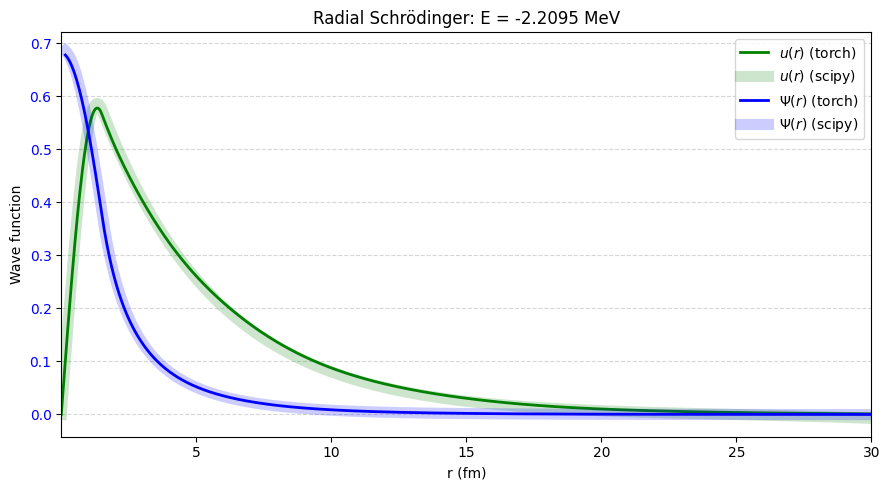

In [60]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn2, R_nn2, metrics2['learned_energy'])